<a href="https://colab.research.google.com/github/ivymist/eple/blob/main/7_stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Practical No:7**

**Aim:Demonstrate recurrent neural network that
learns to perform sequence analysis for stock
price**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv('all_stocks_5yr.csv', delimiter=',')
data['date'] = pd.to_datetime(data['date'])

In [ ]:
netflix = data[data['Name'] == 'NFLX']
netflix = netflix[['date', 'open', 'high', 'low', 'close', 'volume']].sort_values(by='date')

In [ ]:
features = ['open', 'high', 'low', 'close', 'volume']
close_data = netflix[features].values
train_size = max(int(len(close_data) * 0.9), len(close_data) - 100)  # Ensure at least 100 test samples
train_data, test_data = close_data[:train_size], close_data[train_size:]

In [ ]:
if len(train_data) <= 60 or len(test_data) <= 60:
  raise ValueError("Not enough data points for sequence length. Reduce seq_length or increase dataset size.")

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data)
train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

In [ ]:

def create_sequences(data, seq_length=60):
    x, y = [], []
    for i in range(seq_length, len(data)):
        x.append(data[i-seq_length:i])
        y.append(data[i, 3])  # Predicting 'close' price
    x, y = np.array(x), np.array(y)
    print(f"Created sequences: x={x.shape}, y={y.shape}")  # Debugging
    if x.shape[0] == 0:
        raise ValueError("Sequence creation failed. Check data size and seq_length.")
    return x, y
x_train, y_train = create_sequences(train_scaled)
x_test, y_test = create_sequences(test_scaled)

Created sequences: x=(1099, 60, 5), y=(1099,)
Created sequences: x=(40, 60, 5), y=(40,)


In [ ]:

model = keras.Sequential([
    keras.layers.LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.fit(x_train, y_train, epochs=50, batch_size=16, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0493 - val_loss: 0.0318
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0156 - val_loss: 0.0456
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0102 - val_loss: 0.1150
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0095 - val_loss: 0.0337
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0095 - val_loss: 0.0237
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0089 - val_loss: 0.0374
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0072 - val_loss: 0.0351
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0074 - val_loss: 0.0255
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0057 - val_loss: 0.0463
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0047 - val_loss: 0.0344
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0061 - val_loss: 0.0409
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0

In [ ]:
predictions = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


In [ ]:
scaled_test_copy = test_scaled[60:].copy()
scaled_test_copy[:, 3] = predictions[:, 0]  # Replace 'close' price column with predictions
predictions = scaler.inverse_transform(scaled_test_copy)[:, 3]  # Extract 'close' price

In [ ]:
print("Predicted vs Actual Stock Prices:")
for pred, actual in zip(predictions, scaler.inverse_transform(test_scaled[60:])[:, 3]):
    print(f"Predicted: {pred:.2f}, Actual: {actual:.2f}")

Predicted vs Actual Stock Prices:
Predicted: 186.90, Actual: 186.22
Predicted: 188.08, Actual: 185.73
Predicted: 187.87, Actual: 187.86
Predicted: 187.96, Actual: 189.56
Predicted: 189.30, Actual: 190.12
Predicted: 190.41, Actual: 190.42
Predicted: 191.20, Actual: 187.02
Predicted: 190.15, Actual: 188.82
Predicted: 188.94, Actual: 188.62
Predicted: 188.89, Actual: 189.94
Predicted: 188.98, Actual: 187.76
Predicted: 188.71, Actual: 186.24
Predicted: 187.70, Actual: 192.71
Predicted: 189.18, Actual: 191.96
Predicted: 191.49, Actual: 201.07
Predicted: 196.48, Actual: 205.05
Predicted: 202.32, Actual: 205.63
Predicted: 206.30, Actual: 209.99
Predicted: 209.09, Actual: 212.05
Predicted: 211.24, Actual: 209.31
Predicted: 211.65, Actual: 212.52
Predicted: 210.96, Actual: 217.24
Predicted: 213.39, Actual: 221.23
Predicted: 216.99, Actual: 221.53
Predicted: 220.53, Actual: 217.50
Predicted: 220.16, Actual: 220.33
Predicted: 219.41, Actual: 220.46
Predicted: 219.80, Actual: 227.58
Predicted: 222

In [ ]:
dates = netflix['date'].values[train_size + 60:]
train_dates = netflix['date'].values[:train_size]

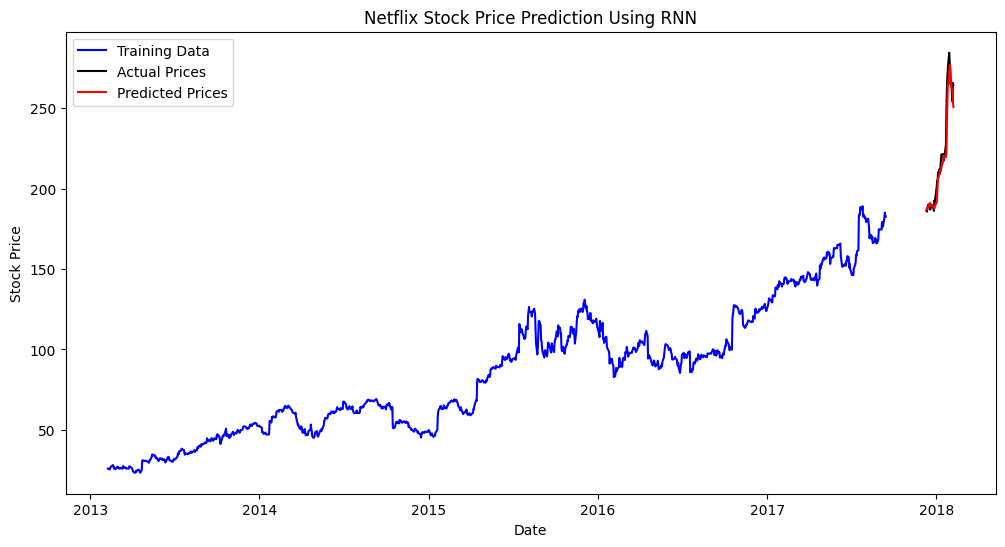

In [ ]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_dates, train_data[:, 3], label='Training Data', color='blue')
plt.plot(dates, test_data[60:, 3], label='Actual Prices', color='black')
plt.plot(dates, predictions, label='Predicted Prices', color='red')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Netflix Stock Price Prediction Using RNN')
plt.legend()
plt.show()